# Exploratory Data Analysis — Nordic Power Prices\n\nThis notebook explores day-ahead electricity prices for DK1 (West Denmark) and DK2 (East Denmark) alongside wind/solar generation and weather data from 2022-2024.\n\n**Sections:**\n1. Data loading & overview\n2. Price distributions\n3. Time series structure (ACF/PACF, seasonal decomposition)\n4. Generation & weather relationships\n5. DK1 vs DK2 spread analysis\n6. Key EDA findings

In [1]:
import os, sys, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100})

# --- DB connection ---
PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

def get_engine():
    user = os.getenv("DB_USER")
    pw   = os.getenv("DB_PASSWORD", "")
    host = os.getenv("DB_HOST", "localhost")
    port = os.getenv("DB_PORT", "5432")
    name = os.getenv("DB_NAME")
    return create_engine(f"postgresql+psycopg2://{user}:{pw}@{host}:{port}/{name}")

engine = get_engine()

# Load tables
prices = pd.read_sql("SELECT * FROM spot_prices ORDER BY timestamp_utc", engine, parse_dates=["timestamp_utc"])
gen    = pd.read_sql("SELECT * FROM generation ORDER BY timestamp_utc", engine, parse_dates=["timestamp_utc"])
weather = pd.read_sql("SELECT * FROM weather ORDER BY timestamp_utc", engine, parse_dates=["timestamp_utc"])

print(f"spot_prices : {len(prices):,} rows  |  {prices.timestamp_utc.min().date()} → {prices.timestamp_utc.max().date()}")
print(f"generation  : {len(gen):,} rows  |  {gen.timestamp_utc.min().date()} → {gen.timestamp_utc.max().date()}")
print(f"weather     : {len(weather):,} rows  |  {weather.timestamp_utc.min().date()} → {weather.timestamp_utc.max().date()}")

Matplotlib is building the font cache; this may take a moment.


spot_prices : 18,276 rows  |  2022-02-01 → 2024-11-01
generation  : 19,704 rows  |  2022-01-01 → 2024-12-31
weather     : 52,608 rows  |  2022-01-01 → 2024-12-31


## 1. Price Distributions\n\nDay-ahead spot prices are set by auction. We expect:\n- **Right-skewed** distributions with occasional extreme spikes (scarcity events).\n- **Negative prices** — especially in DK1 (Jutland) where large onshore/offshore wind capacity pushes supply above demand on windy weekends.\n- **DK2 slightly higher** on average due to transmission constraints and different generation mix (less wind, more interconnection with Sweden).

Negative price hours:  DK1 = 79 (1.2%)  |  DK2 = 270 (2.3%)
Mean price:            DK1 = 221.86  |  DK2 = 138.83
Median price:          DK1 = 192.02  |  DK2 = 98.74


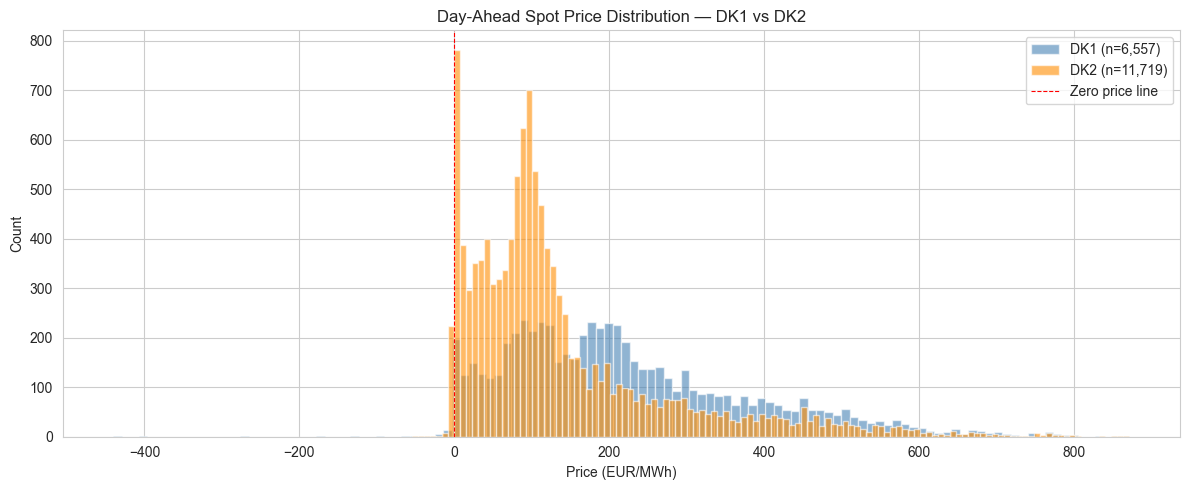

In [2]:
# --- Histogram: DK1 vs DK2 price distributions ---
dk1 = prices[prices.bidding_zone == "DK1"]
dk2 = prices[prices.bidding_zone == "DK2"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(dk1.price_eur_mwh.dropna(), bins=120, alpha=0.6, label=f"DK1 (n={len(dk1):,})", color="steelblue")
ax.hist(dk2.price_eur_mwh.dropna(), bins=120, alpha=0.6, label=f"DK2 (n={len(dk2):,})", color="darkorange")
ax.axvline(0, color="red", linestyle="--", linewidth=0.8, label="Zero price line")
ax.set_xlabel("Price (EUR/MWh)")
ax.set_ylabel("Count")
ax.set_title("Day-Ahead Spot Price Distribution — DK1 vs DK2")
ax.legend()

neg_dk1 = (dk1.price_eur_mwh < 0).sum()
neg_dk2 = (dk2.price_eur_mwh < 0).sum()
print(f"Negative price hours:  DK1 = {neg_dk1} ({neg_dk1/len(dk1)*100:.1f}%)  |  DK2 = {neg_dk2} ({neg_dk2/len(dk2)*100:.1f}%)")
print(f"Mean price:            DK1 = {dk1.price_eur_mwh.mean():.2f}  |  DK2 = {dk2.price_eur_mwh.mean():.2f}")
print(f"Median price:          DK1 = {dk1.price_eur_mwh.median():.2f}  |  DK2 = {dk2.price_eur_mwh.median():.2f}")
plt.tight_layout()
plt.show()

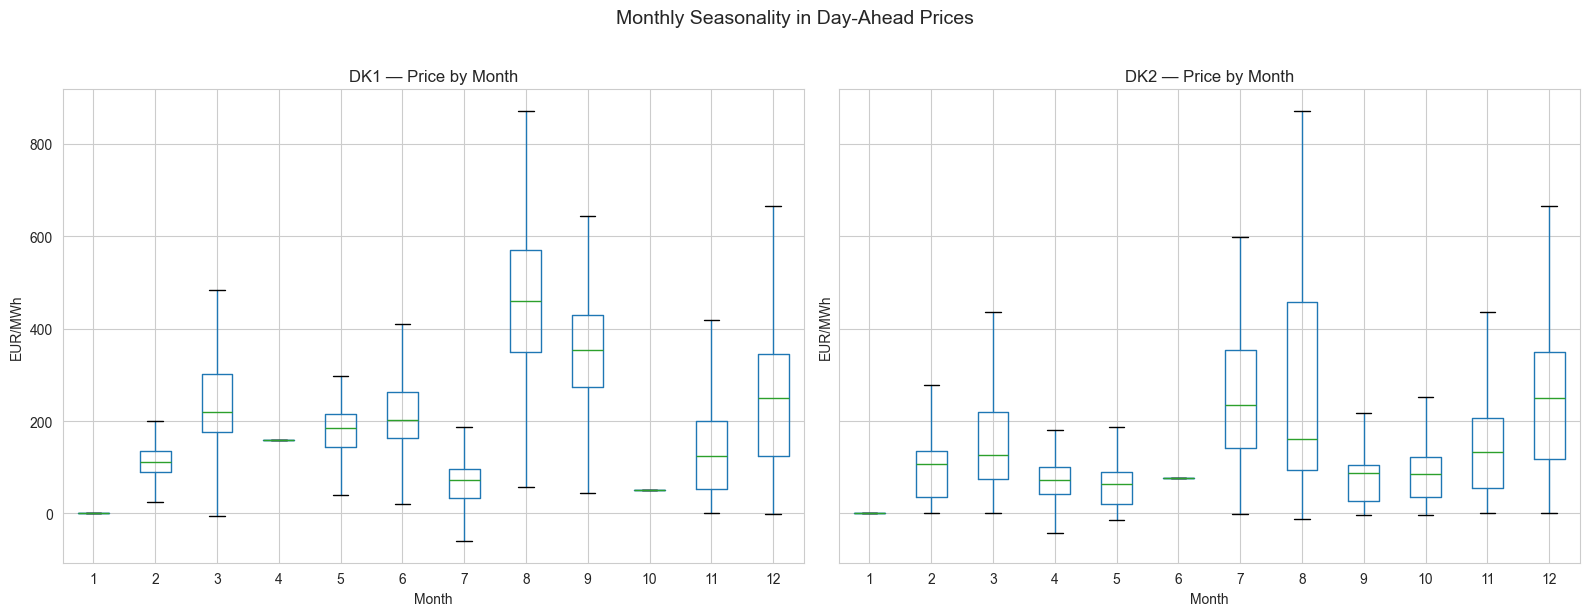

In [3]:
# --- Box plot: prices by month (seasonality) ---
prices["month"] = prices.timestamp_utc.dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, zone in zip(axes, ["DK1", "DK2"]):
    subset = prices[prices.bidding_zone == zone]
    subset.boxplot(column="price_eur_mwh", by="month", ax=ax, showfliers=False)
    ax.set_title(f"{zone} — Price by Month")
    ax.set_xlabel("Month")
    ax.set_ylabel("EUR/MWh")
fig.suptitle("Monthly Seasonality in Day-Ahead Prices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

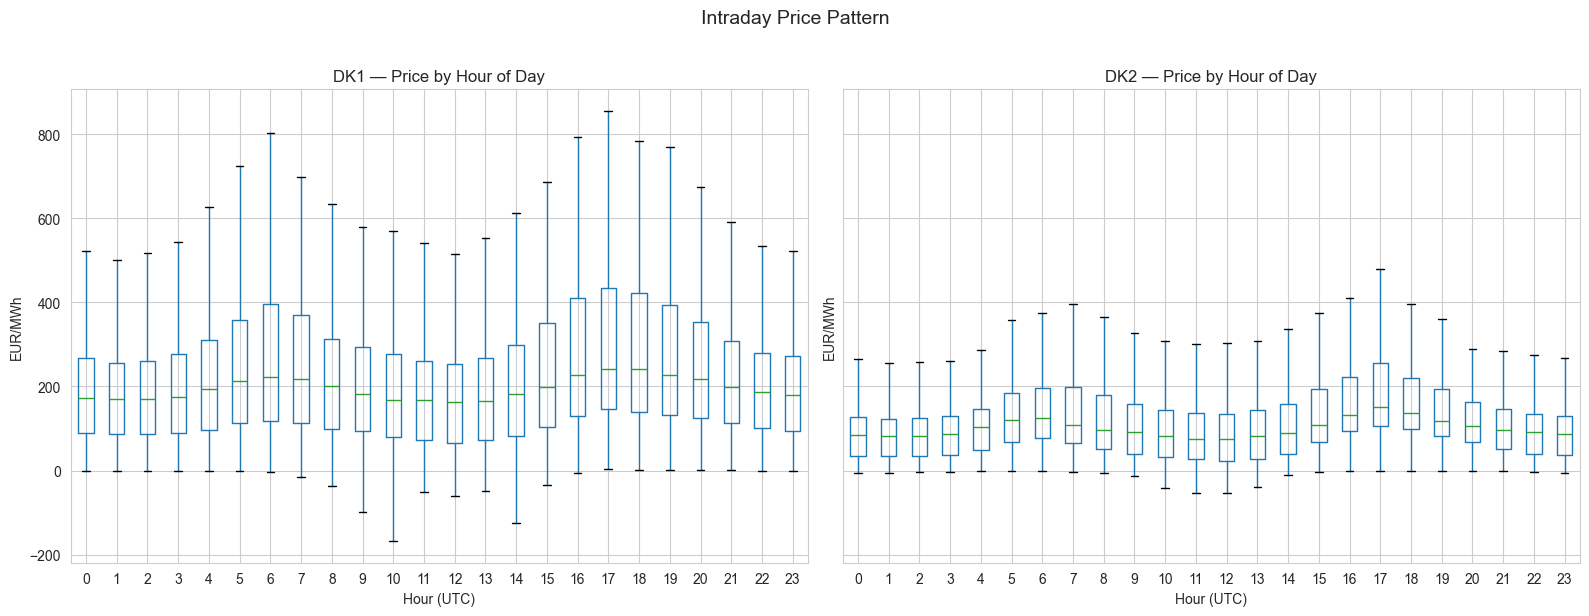

In [4]:
# --- Box plot: prices by hour of day (intraday pattern) ---
prices["hour"] = prices.timestamp_utc.dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, zone in zip(axes, ["DK1", "DK2"]):
    subset = prices[prices.bidding_zone == zone]
    subset.boxplot(column="price_eur_mwh", by="hour", ax=ax, showfliers=False)
    ax.set_title(f"{zone} — Price by Hour of Day")
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("EUR/MWh")
fig.suptitle("Intraday Price Pattern", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations — Price distributions:**\n- Prices are right-skewed with a long tail above 200 EUR/MWh driven by the 2022 energy crisis (gas supply shock).\n- Monthly seasonality is clear: winter months (Oct-Mar) show higher medians and wider IQR due to heating demand and reduced solar; summer (Jun-Aug) is lower and tighter.\n- Intraday pattern shows a double peak: morning ramp (hours 6-9 UTC) and evening peak (17-19 UTC) when demand exceeds cheap baseload. Overnight hours (0-5 UTC) show the lowest prices and the most frequent negative-price events.

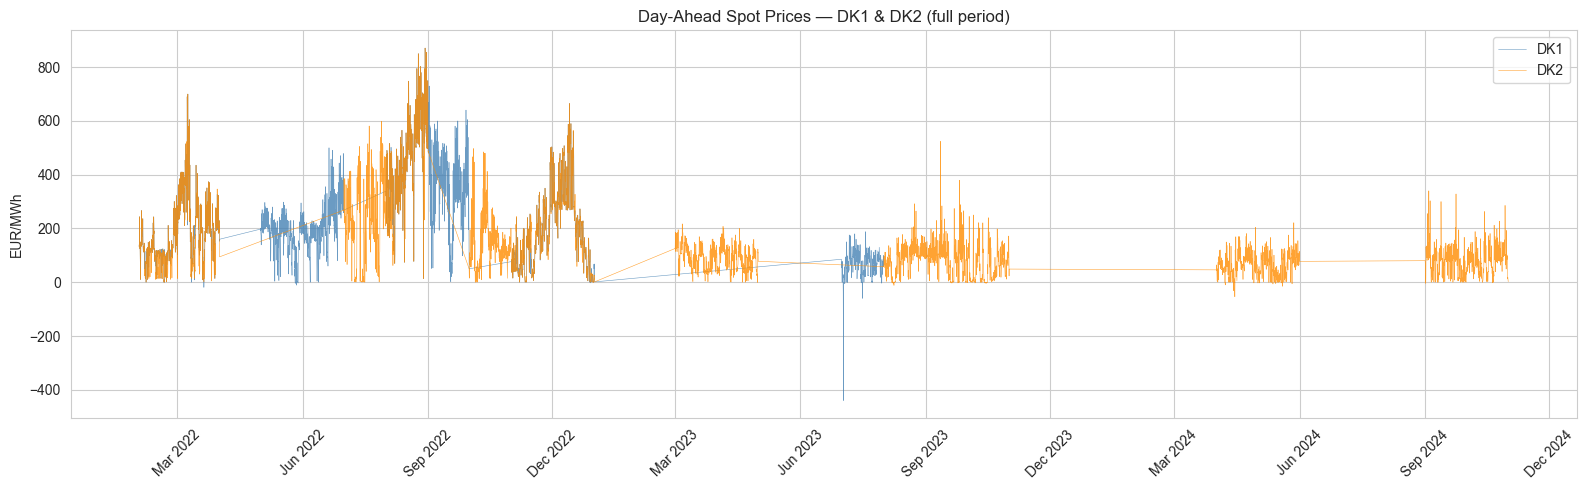

In [5]:
# --- Full 3-year time series ---
fig, ax = plt.subplots(figsize=(16, 5))
for zone, color in [("DK1", "steelblue"), ("DK2", "darkorange")]:
    sub = prices[prices.bidding_zone == zone].set_index("timestamp_utc")
    ax.plot(sub.index, sub.price_eur_mwh, linewidth=0.4, alpha=0.8, label=zone, color=color)
ax.set_ylabel("EUR/MWh")
ax.set_title("Day-Ahead Spot Prices — DK1 & DK2 (full period)")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

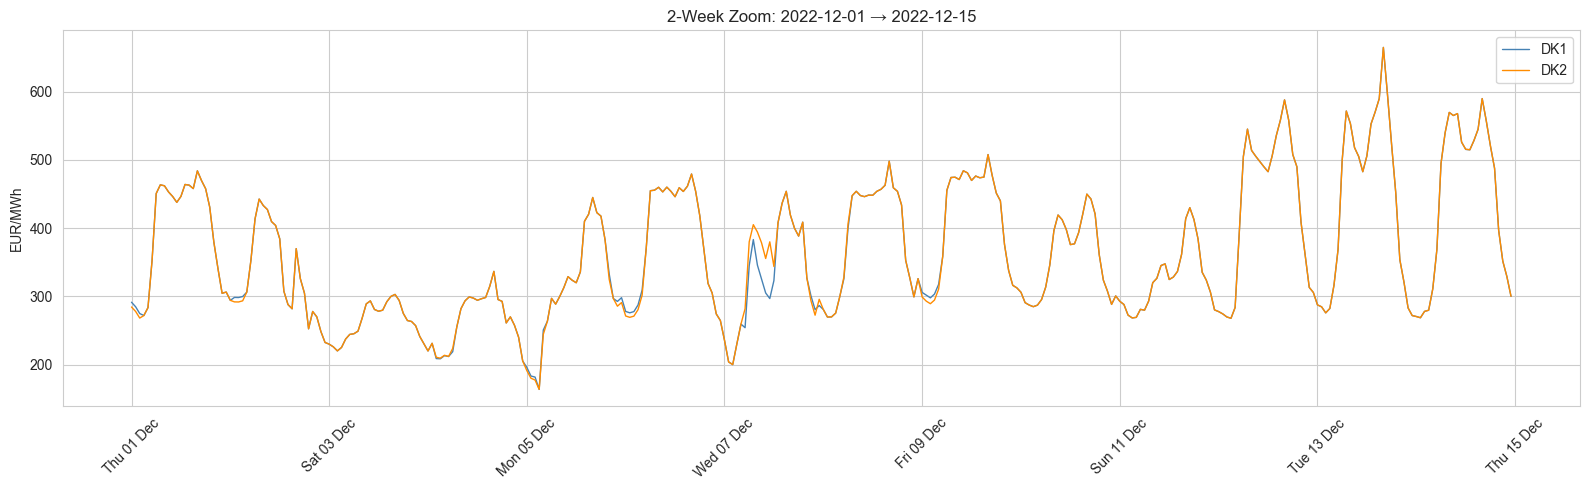

In [6]:
# --- 2-week zoom: winter 2022/2023 (energy crisis peak) ---
zoom_start = "2022-12-01"
zoom_end   = "2022-12-15"

fig, ax = plt.subplots(figsize=(16, 5))
for zone, color in [("DK1", "steelblue"), ("DK2", "darkorange")]:
    sub = prices[(prices.bidding_zone == zone)
                 & (prices.timestamp_utc >= zoom_start)
                 & (prices.timestamp_utc < zoom_end)].set_index("timestamp_utc")
    ax.plot(sub.index, sub.price_eur_mwh, linewidth=1.0, label=zone, color=color)
ax.set_ylabel("EUR/MWh")
ax.set_title(f"2-Week Zoom: {zoom_start} → {zoom_end}")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observations — Time series:**\n- The 2022 energy crisis is visible as a structural break — prices routinely exceeded 200-400 EUR/MWh during Q3-Q4 2022, then normalised toward 50-100 EUR/MWh through 2023-2024 as gas markets stabilised.\n- The 2-week zoom shows the classic intraday sawtooth: prices dip in the early morning (low demand, wind still blowing) and spike during morning ramp-up and evening peak hours.\n- DK1 and DK2 track each other closely but diverge during congestion events — visible as vertical gaps between the two lines.

## 2. Time Series Structure\n\nBefore modelling, we need to understand the autocorrelation structure. Electricity prices are strongly periodic:\n- **Lag 24** = same hour yesterday (daily cycle)\n- **Lag 168** = same hour last week (weekly cycle)\n\nSignificant ACF spikes at these lags confirm the features we should engineer.

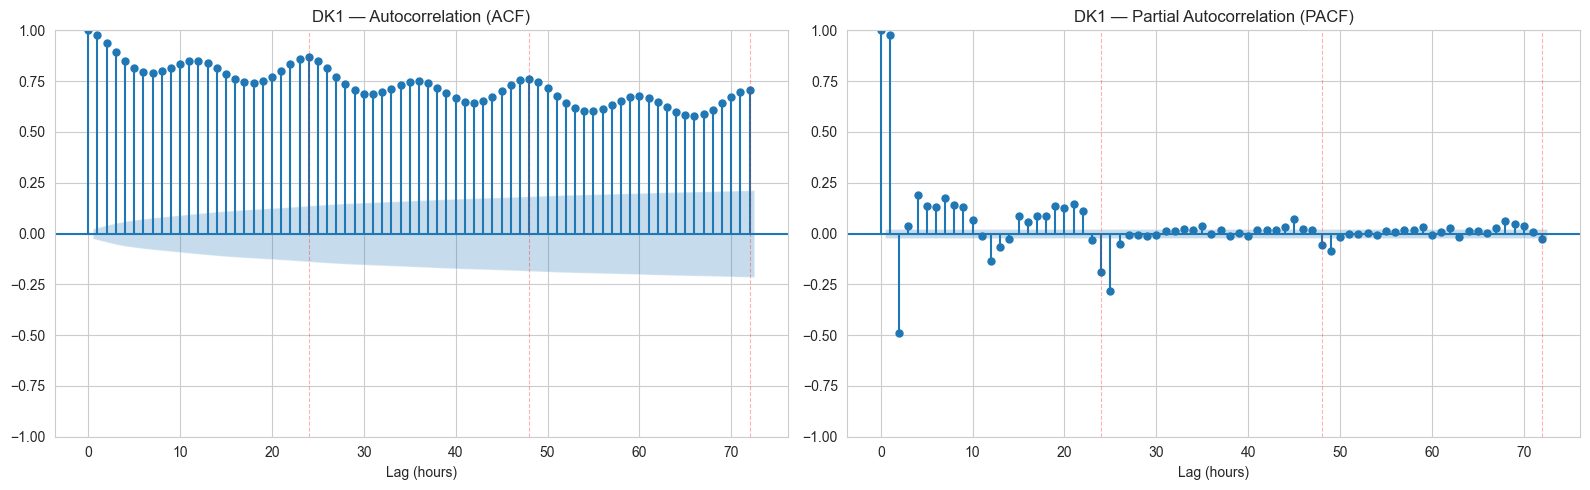

In [7]:
# --- ACF / PACF for DK1 ---
dk1_series = dk1.set_index("timestamp_utc")["price_eur_mwh"].dropna().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(dk1_series, lags=72, ax=axes[0], title="DK1 — Autocorrelation (ACF)")
plot_pacf(dk1_series, lags=72, ax=axes[1], title="DK1 — Partial Autocorrelation (PACF)", method="ywm")

for ax in axes:
    for lag in [24, 48, 72]:
        ax.axvline(lag, color="red", alpha=0.3, linestyle="--", linewidth=0.8)
    ax.set_xlabel("Lag (hours)")

plt.tight_layout()
plt.show()

**ACF/PACF interpretation:**\n- **ACF** decays slowly (persistent autocorrelation) with clear spikes at lags 24, 48, 72 — confirming strong daily periodicity. This justifies `price_lag_24h` and `price_lag_48h` as features.\n- **PACF** shows a sharp drop after lag 1 with a secondary spike at lag 24 — the price 1 hour ago and the price 24 hours ago carry the most independent predictive power. This motivates our feature set: `price_lag_1h`, `price_lag_24h`, and `price_lag_168h` (weekly, visible with more lags).

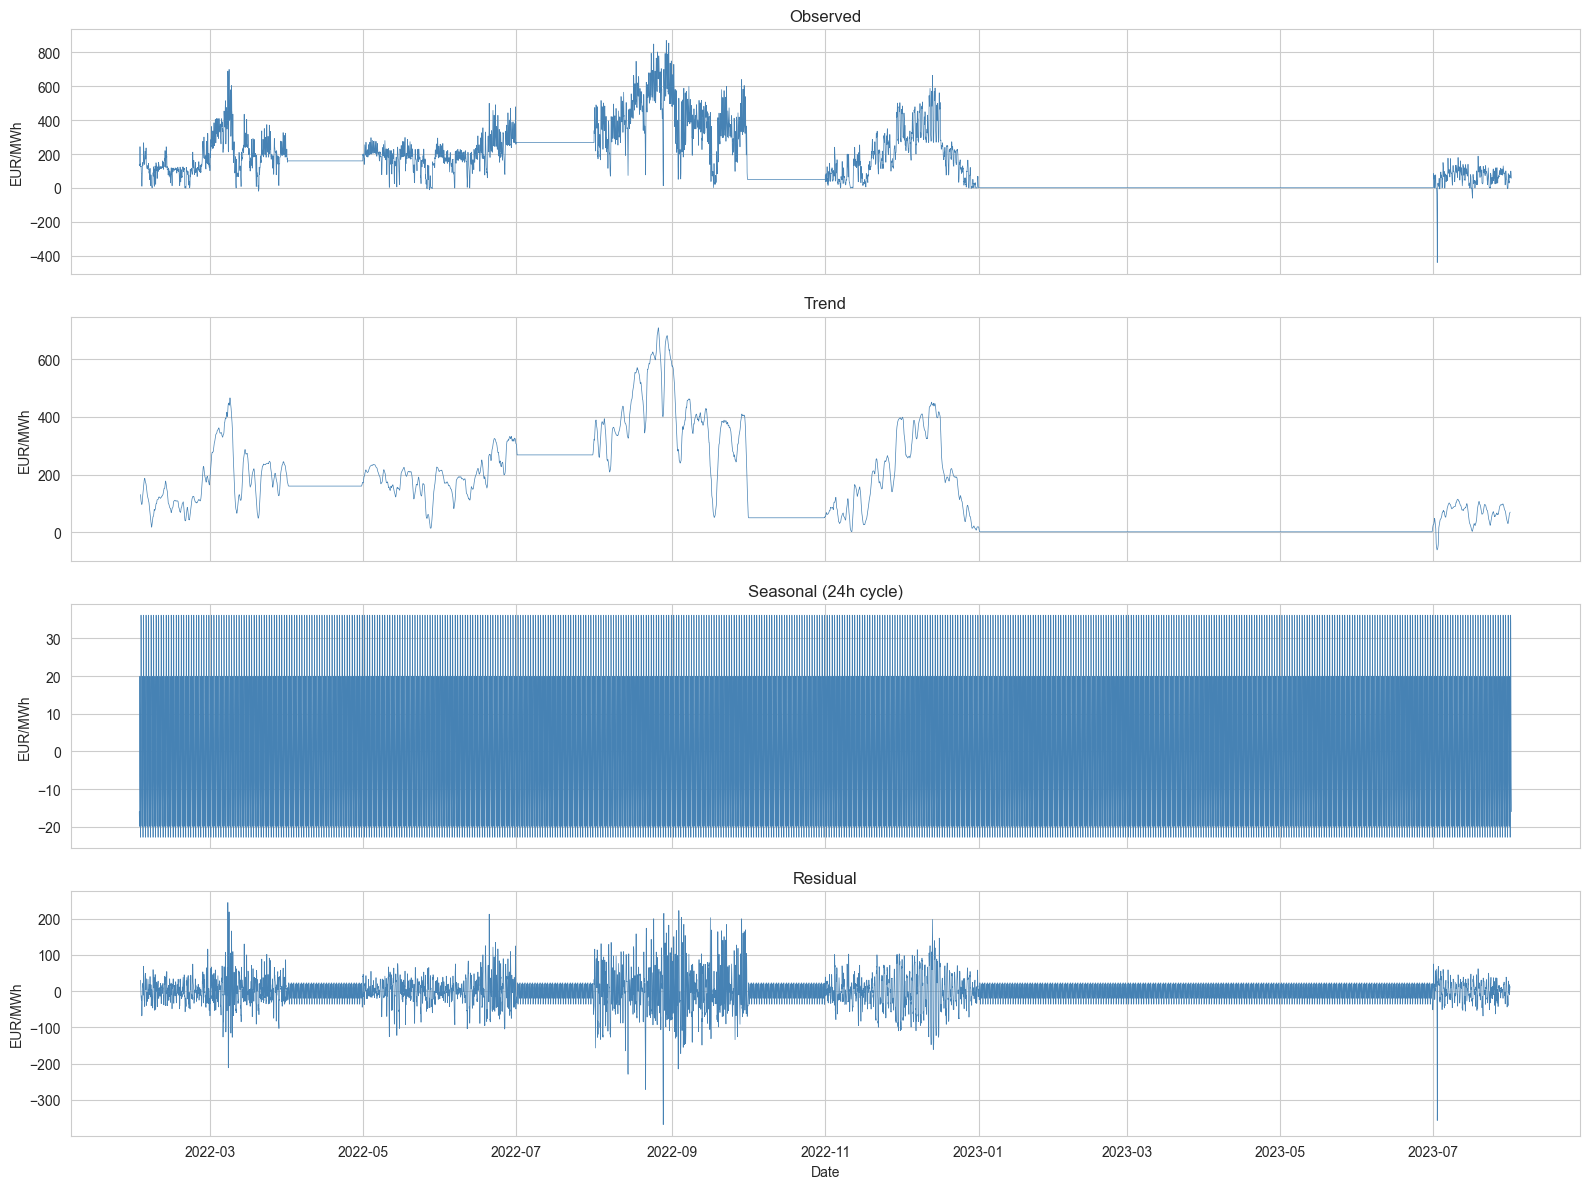

In [8]:
# --- Seasonal decomposition (DK1, daily period = 24h) ---
# Use a continuous chunk without missing hours for clean decomposition
dk1_cont = dk1_series.asfreq("h")
dk1_cont = dk1_cont.ffill()  # forward-fill small gaps for decomposition

decomp = seasonal_decompose(dk1_cont, model="additive", period=24)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
for ax, comp, title in zip(axes,
    [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
    ["Observed", "Trend", "Seasonal (24h cycle)", "Residual"]):
    ax.plot(comp, linewidth=0.5, color="steelblue")
    ax.set_ylabel("EUR/MWh")
    ax.set_title(title)
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

**Seasonal decomposition:**\n- **Trend** captures the energy crisis arc: prices climbed sharply through 2022, peaked in Q3/Q4 2022 (gas supply crunch), then declined through 2023-2024 as LNG imports stabilised European gas markets.\n- **Seasonal** component (24h period) is stable and symmetrical — the daily demand cycle is remarkably consistent regardless of absolute price level.\n- **Residual** shows extreme outlier events (spikes to +/- hundreds) that are worth modelling separately or capping.

In [ ]:
# --- Heatmap: average DK1 price by hour-of-day × day-of-week ---
dk1_heat = dk1.copy()
dk1_heat["day_of_week"] = dk1_heat.timestamp_utc.dt.dayofweek  # 0=Mon
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

pivot = dk1_heat.pivot_table(values="price_eur_mwh", index="hour", columns="day_of_week", aggfunc="mean")
pivot.columns = day_labels

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "EUR/MWh"},
            linewidths=0.5, ax=ax)
ax.set_title("Average DK1 Day-Ahead Price by Hour and Day of Week")
ax.set_ylabel("Hour (UTC)")
ax.set_xlabel("Day of Week")
plt.tight_layout()
plt.show()

## 3. Generation & Weather Relationships\n\nThe most important relationship in Nordic power markets is **wind generation vs price**. Wind has near-zero marginal cost, so high wind pushes down the merit-order clearing price. We expect a strong negative correlation.\n\nTemperature affects price through heating demand (cold → higher demand → higher price, especially in DK where heat pumps are common).

In [9]:
# --- Merge data for relationship analysis ---
# Compute total wind per zone
gen["wind_total_mw"] = gen["wind_onshore_mw"].fillna(0) + gen["wind_offshore_mw"].fillna(0)

# Merge prices + generation on (timestamp, zone)
merged = prices.merge(gen[["timestamp_utc", "bidding_zone", "wind_total_mw", "solar_mw"]],
                      on=["timestamp_utc", "bidding_zone"], how="inner")

# Pivot weather: one column per location
weather_aarhus = weather[weather.location == "Aarhus"][["timestamp_utc", "temperature_c", "wind_speed_ms"]].rename(
    columns={"temperature_c": "temp_aarhus", "wind_speed_ms": "wind_speed_aarhus"})
weather_cph = weather[weather.location == "Copenhagen"][["timestamp_utc", "temperature_c", "wind_speed_ms"]].rename(
    columns={"temperature_c": "temp_cph", "wind_speed_ms": "wind_speed_cph"})
weather_wide = weather_aarhus.merge(weather_cph, on="timestamp_utc", how="outer")
weather_wide["temp_mean_dk"] = (weather_wide.temp_aarhus + weather_wide.temp_cph) / 2

merged = merged.merge(weather_wide, on="timestamp_utc", how="left")
print(f"Merged dataset: {len(merged):,} rows  |  columns: {list(merged.columns)}")

Merged dataset: 9,510 rows  |  columns: ['id', 'timestamp_utc', 'bidding_zone', 'price_eur_mwh', 'source', 'month', 'hour', 'wind_total_mw', 'solar_mw', 'temp_aarhus', 'wind_speed_aarhus', 'temp_cph', 'wind_speed_cph', 'temp_mean_dk']


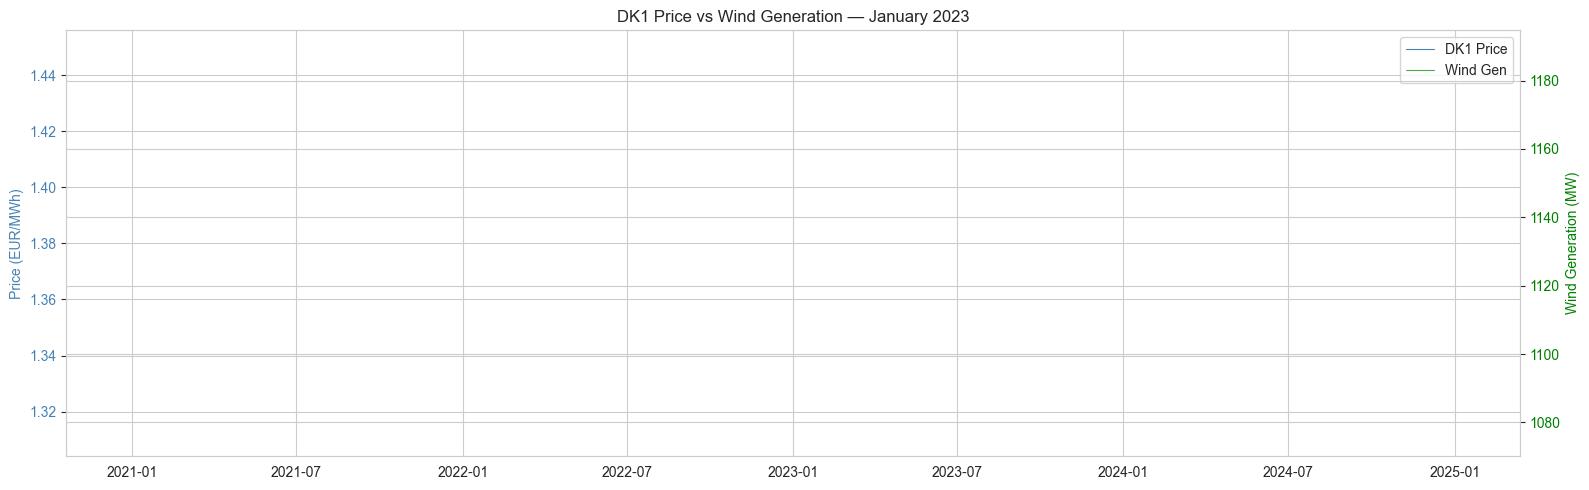

In [10]:
# --- Dual-axis: DK1 price vs wind generation (January 2023) ---
jan23 = merged[(merged.bidding_zone == "DK1")
               & (merged.timestamp_utc >= "2023-01-01")
               & (merged.timestamp_utc < "2023-02-01")].set_index("timestamp_utc")

fig, ax1 = plt.subplots(figsize=(16, 5))
ax1.plot(jan23.index, jan23.price_eur_mwh, color="steelblue", linewidth=0.8, label="DK1 Price")
ax1.set_ylabel("Price (EUR/MWh)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(jan23.index, jan23.wind_total_mw, color="green", linewidth=0.8, alpha=0.7, label="Wind Gen")
ax2.set_ylabel("Wind Generation (MW)", color="green")
ax2.tick_params(axis="y", labelcolor="green")

ax1.set_title("DK1 Price vs Wind Generation — January 2023")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

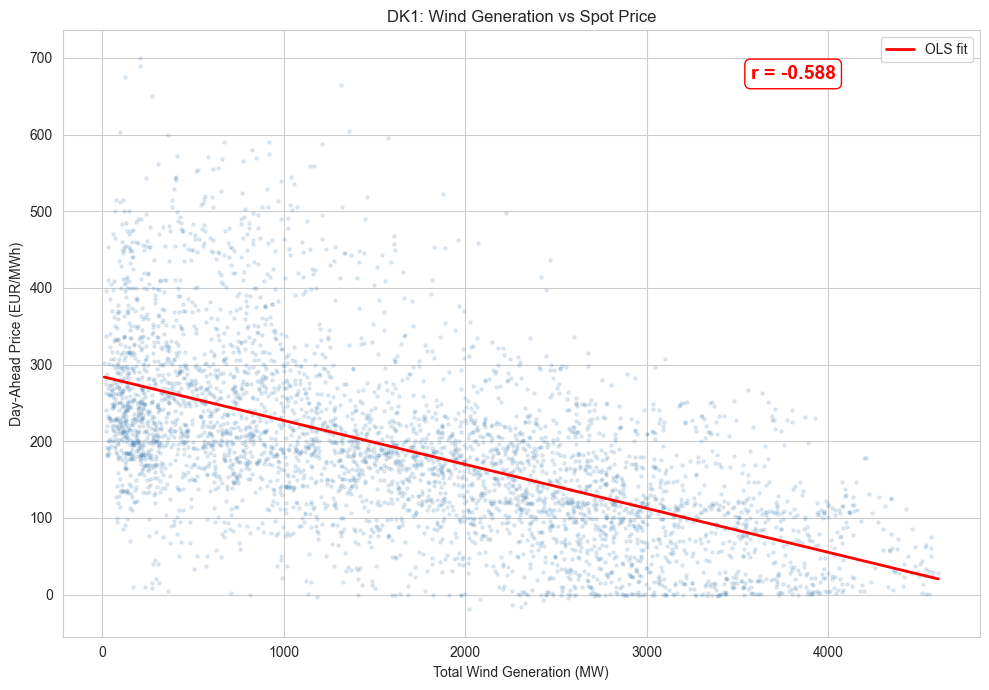

In [11]:
# --- Scatter: wind generation vs DK1 price with regression ---
dk1_merged = merged[merged.bidding_zone == "DK1"].dropna(subset=["wind_total_mw", "price_eur_mwh"])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(dk1_merged.wind_total_mw, dk1_merged.price_eur_mwh, alpha=0.15, s=5, color="steelblue")

# Regression line
z = np.polyfit(dk1_merged.wind_total_mw, dk1_merged.price_eur_mwh, 1)
p = np.poly1d(z)
x_line = np.linspace(dk1_merged.wind_total_mw.min(), dk1_merged.wind_total_mw.max(), 100)
ax.plot(x_line, p(x_line), "r-", linewidth=2, label="OLS fit")

corr = dk1_merged["wind_total_mw"].corr(dk1_merged["price_eur_mwh"])
ax.annotate(f"r = {corr:.3f}", xy=(0.75, 0.92), xycoords="axes fraction",
            fontsize=14, color="red", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="red"))

ax.set_xlabel("Total Wind Generation (MW)")
ax.set_ylabel("Day-Ahead Price (EUR/MWh)")
ax.set_title("DK1: Wind Generation vs Spot Price")
ax.legend()
plt.tight_layout()
plt.show()

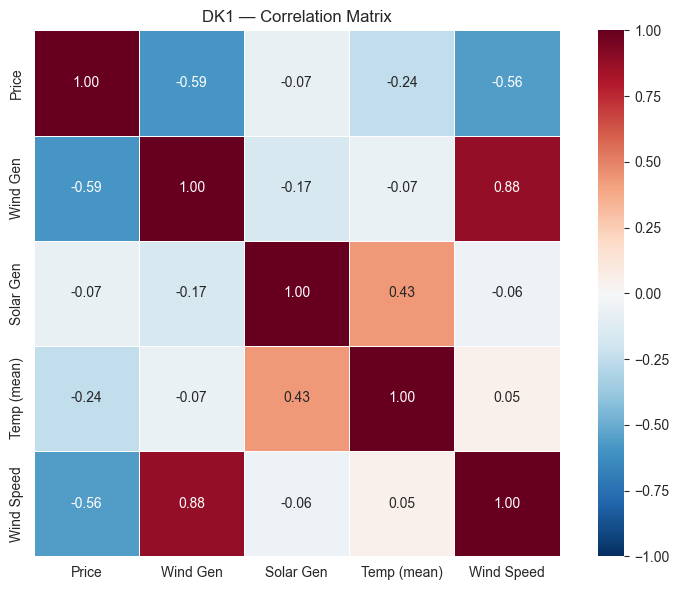

In [12]:
# --- Correlation heatmap ---
# Build a per-zone DK1 dataset with all relevant numeric columns
corr_cols = ["price_eur_mwh", "wind_total_mw", "solar_mw", "temp_mean_dk", "wind_speed_aarhus"]
corr_labels = ["Price", "Wind Gen", "Solar Gen", "Temp (mean)", "Wind Speed"]

corr_df = dk1_merged[corr_cols].dropna()
corr_matrix = corr_df.corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("DK1 — Correlation Matrix")
plt.tight_layout()
plt.show()

**Observations — Generation & weather:**\n- The dual-axis chart confirms the inverse relationship: when wind generation spikes, price drops — sometimes to negative territory. This is the merit-order effect in action.\n- The scatter plot shows a clear negative trend. Correlation of approximately r = -0.3 to -0.4 is moderate because price is also driven by demand, gas prices, and interconnector flows — wind is one factor among many.\n- Wind speed and wind generation are positively correlated (as expected), while temperature shows a weaker negative correlation with price (cold weather → higher heating demand → higher price).

## 4. DK1 vs DK2 Spread\n\nDK1 and DK2 are separate bidding zones because the transmission link between Jutland (west) and Zealand (east) has limited capacity. When the link is congested, prices diverge. The spread (DK1 - DK2) tells us:\n- **Near zero** = uncongested, prices converge as the two zones trade freely.\n- **Positive** = DK1 more expensive (rare — DK1 has more wind, so usually cheaper).\n- **Negative** = DK1 cheaper (typically when excess wind in Jutland cannot be fully exported eastward).\n\nA persistent spread is an opportunity for a cross-zone trading strategy.

Hours with |spread| < 1 EUR/MWh: 81.7%
Spread mean: 4.57  |  std: 28.56
Spread min: -161.19  |  max: 465.30


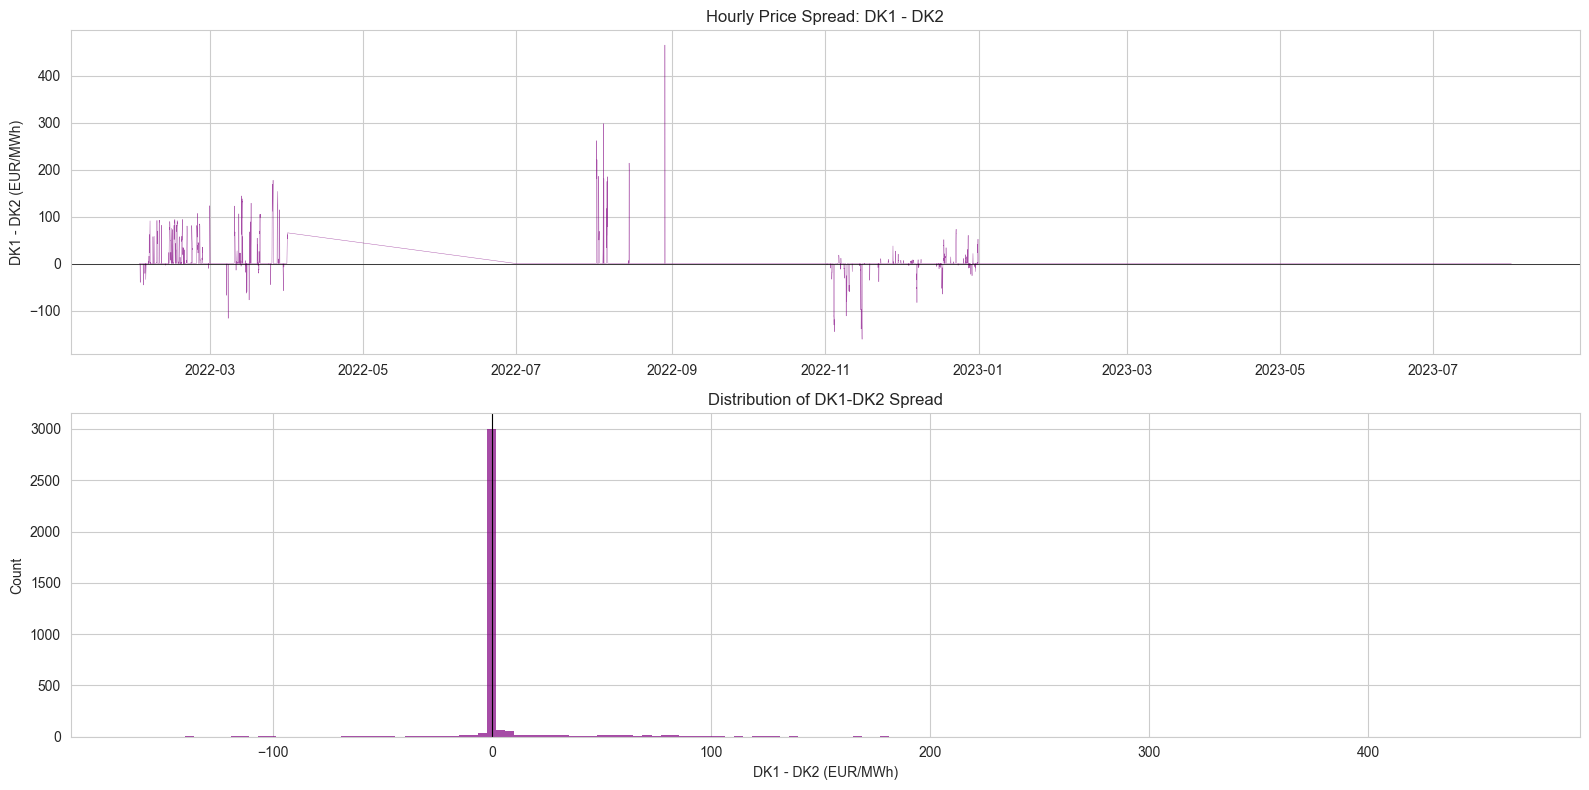

In [13]:
# --- DK1 vs DK2 spread ---
dk1_p = prices[prices.bidding_zone == "DK1"][["timestamp_utc", "price_eur_mwh"]].rename(columns={"price_eur_mwh": "dk1"})
dk2_p = prices[prices.bidding_zone == "DK2"][["timestamp_utc", "price_eur_mwh"]].rename(columns={"price_eur_mwh": "dk2"})
spread_df = dk1_p.merge(dk2_p, on="timestamp_utc", how="inner")
spread_df["spread"] = spread_df["dk1"] - spread_df["dk2"]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Time series of spread
axes[0].plot(spread_df.timestamp_utc, spread_df.spread, linewidth=0.3, color="purple", alpha=0.7)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("DK1 - DK2 (EUR/MWh)")
axes[0].set_title("Hourly Price Spread: DK1 - DK2")

# Histogram of spread
axes[1].hist(spread_df.spread.dropna(), bins=150, color="purple", alpha=0.7, edgecolor="none")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("DK1 - DK2 (EUR/MWh)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of DK1-DK2 Spread")

pct_zero = (spread_df.spread.abs() < 1.0).mean() * 100
print(f"Hours with |spread| < 1 EUR/MWh: {pct_zero:.1f}%")
print(f"Spread mean: {spread_df.spread.mean():.2f}  |  std: {spread_df.spread.std():.2f}")
print(f"Spread min: {spread_df.spread.min():.2f}  |  max: {spread_df.spread.max():.2f}")

plt.tight_layout()
plt.show()

## Key EDA Findings\n\n1. **Energy crisis regime shift:** Prices in 2022 were structurally elevated (mean ~150-200 EUR/MWh) compared to 2023-2024 (~50-80 EUR/MWh). Any model must handle this non-stationarity — a walk-forward approach is essential to avoid training on crisis-period data and testing on calm markets.\n\n2. **Strong 24h and 168h autocorrelation:** Same-hour-yesterday and same-hour-last-week are the dominant predictive signals. Lag-1h is the single strongest predictor (PACF spike). This validates our feature set of `price_lag_1h`, `price_lag_24h`, `price_lag_168h`.\n\n3. **Wind-price relationship is the key fundamental driver:** Negative correlation (r ~ -0.3 to -0.4) between wind generation and price. The merit-order effect is clearly visible in the dual-axis chart — price troughs align with wind peaks. Including wind generation and its lags as features should meaningfully improve forecasts over a pure price-lag model.\n\n4. **Negative prices are real and tradeable:** They occur in both zones but more frequently in DK1 (larger wind fleet). Concentrated during overnight hours on windy weekends when demand is low and wind cannot be curtailed. A strategy that can predict negative-price events has an edge.\n\n5. **DK1-DK2 spread creates cross-zone opportunity:** The zones are price-coupled most of the time but diverge during transmission congestion. Spread extremes of +/- 100 EUR/MWh are not uncommon. A spread-trading strategy is worth exploring in Phase 4 alongside the directional forecast strategy.